In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

df = pd.read_csv("../data/processed/customer_churn_features.csv")

print(df.shape)

(7043, 36)


In [2]:
drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Value",
    "Churn Score",
    "Churn Reason",
    "CLTV"
]

X = df.drop(columns=drop_columns)
y = df["Churn Label"].map({"No": 0, "Yes": 1})

print("X Shape:", X.shape)
print("\nTarget Distribution:")
print(y.value_counts())

X Shape: (7043, 22)

Target Distribution:
Churn Label
0    5174
1    1869
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

print("\nTraining Target:")
print(y_train.value_counts())

print("\nTesting Target:")
print(y_test.value_counts())

Training Data: (5634, 22)
Testing Data: (1409, 22)

Training Target:
Churn Label
0    4139
1    1495
Name: count, dtype: int64

Testing Target:
Churn Label
0    1035
1     374
Name: count, dtype: int64


In [4]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "str", "category"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nTotal Numerical:", len(numeric_features))
print("Total Categorical:", len(categorical_features))

Numerical Features:
['Tenure Months', 'Monthly Charges', 'Total Charges', 'Service_Count', 'Average_Monthly_Spend']

Categorical Features:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Tenure_Group']

Total Numerical: 5
Total Categorical: 17


In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [6]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

print("Models created successfully!")


Models created successfully!


In [8]:
print("Missing values in X:")
print(X.isnull().sum()[X.isnull().sum() > 0])

print("\nInfinite values in numerical columns:")
for col in numeric_features:
    print(col, np.isinf(pd.to_numeric(X[col], errors="coerce")).sum())

Missing values in X:
Total Charges            11
Average_Monthly_Spend    11
dtype: int64

Infinite values in numerical columns:
Tenure Months 0
Monthly Charges 0
Total Charges 0
Service_Count 0
Average_Monthly_Spend 0


In [9]:
# Fix missing numerical values

df["Total Charges"] = df["Total Charges"].fillna(
    df["Total Charges"].median()
)

df["Average_Monthly_Spend"] = df["Average_Monthly_Spend"].fillna(
    df["Average_Monthly_Spend"].median()
)

print("Remaining Missing Values:")
print(df[["Total Charges", "Average_Monthly_Spend"]].isnull().sum())

Remaining Missing Values:
Total Charges            0
Average_Monthly_Spend    0
dtype: int64


In [10]:
X = df.drop(columns=drop_columns)
y = df["Churn Label"].map({"No": 0, "Yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Missing in X:", X.isnull().sum().sum())
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Missing in X: 0
Training: (5634, 22)
Testing: (1409, 22)


In [11]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    roc_auc = roc_auc_score(y_test, probabilities)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.748758   0.517544  0.788770  0.625000  0.849306
1        Decision Tree  0.724627   0.482587  0.518717  0.500000  0.659126
2        Random Forest  0.771469   0.559908  0.649733  0.601485  0.833608
3    Gradient Boosting  0.797019   0.647651  0.516043  0.574405  0.851183


In [12]:
# Select Logistic Regression as final model

best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", models["Logistic Regression"])
])

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Final Model: Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Final Model: Logistic Regression
Accuracy: 0.7487579843860894
Precision: 0.5175438596491229
Recall: 0.7887700534759359
F1 Score: 0.625


In [14]:
import matplotlib.pyplot as plt

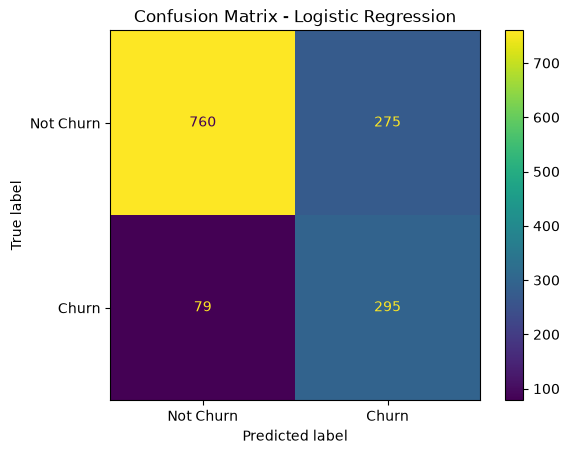

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

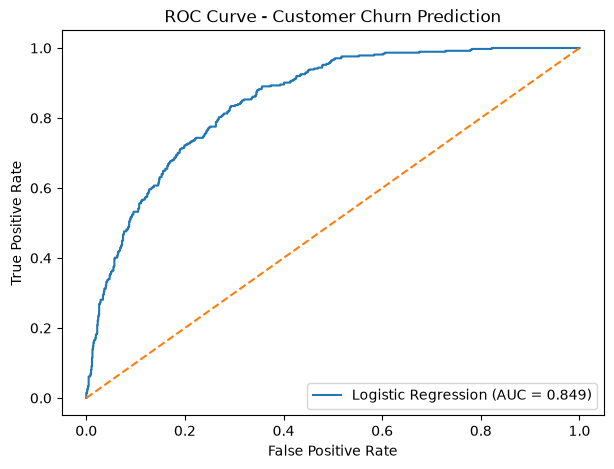

ROC-AUC Score: 0.8493063628613501


In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Prediction")
plt.legend()

plt.show()

print("ROC-AUC Score:", roc_auc)

In [17]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/churn_model.pkl")

print("Final churn model saved successfully!")

Final churn model saved successfully!


In [18]:
# Churn probability for test customers
churn_probabilities = best_model.predict_proba(X_test)[:, 1]

results = X_test.copy()

results["Actual_Churn"] = y_test.values
results["Predicted_Churn"] = y_pred
results["Churn_Probability"] = churn_probabilities

# Convert probability into risk category
def risk_level(probability):
    if probability < 0.30:
        return "Low"
    elif probability < 0.60:
        return "Medium"
    else:
        return "High"

results["Risk_Level"] = results["Churn_Probability"].apply(risk_level)

results[
    ["Actual_Churn", "Predicted_Churn",
     "Churn_Probability", "Risk_Level"]
].head(10)

,Actual_Churn,Predicted_Churn,Churn_Probability,Risk_Level
2196,0,0,0.172464,Low
3549,0,1,0.877261,High
3515,0,0,0.215391,Low
5162,0,1,0.665688,High
4642,0,0,0.096149,Low
6096,0,1,0.778561,High
4504,0,1,0.655298,High
4067,0,0,0.090159,Low
6233,0,0,0.005393,Low
430,1,1,0.570216,Medium


In [19]:
import os

os.makedirs("../data/processed", exist_ok=True)

results.to_csv(
    "../data/processed/churn_predictions.csv",
    index=False
)

print("Prediction results saved successfully!")
print("Total predictions:", len(results))

Prediction results saved successfully!
Total predictions: 1409
